# Supply Chain V3 — Shipment Performance Analysis

This notebook evaluates the business performance of simulated shipments.

## Analytical question

**How do routes, operational disruptions, and vehicle behavior affect shipment delivery performance?**

The analysis focuses on:

- scheduled versus actual arrival
- shipment duration
- on-time delivery
- route performance
- disruption exposure
- priority shipments
- vehicle assignment
- delivery outcomes

This notebook extends the previous analytics sequence:

1. Fleet telemetry
2. Disruption impact
3. Shipment business performance

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

cwd = Path.cwd()
repo_root = cwd if (cwd / "pyproject.toml").exists() else cwd.parent

load_dotenv(repo_root / ".env")

database_url = os.getenv("DATABASE_URL")
if not database_url:
    raise RuntimeError(
        "DATABASE_URL is not set. Copy .env.example to .env first."
    )

engine = create_engine(database_url)

print("SQLAlchemy engine configured for TimescaleDB")

SQLAlchemy engine configured for TimescaleDB


## 1. Profile the shipment population

Before calculating performance metrics, inspect the available shipment population.

The grain of `sc_shipments` is:

**one row = one shipment**

This first query examines shipment lifecycle, scheduling, actual completion timestamps,
priority, route assignment, and vehicle assignment.

In [2]:
shipment_profile_sql = """
SELECT
    shipment_id,
    run_id,
    vehicle_id,
    route_id,
    origin_wh_id,
    dest_wh_id,
    cargo_type,
    priority,
    lifecycle_status,
    scheduled_departure,
    scheduled_arrival,
    actual_departure,
    actual_arrival,
    estimated_arrival,
    delivery_completed_at
FROM sc_shipments
ORDER BY shipment_id;
"""

shipments = pd.read_sql_query(
    shipment_profile_sql,
    engine,
)

shipments.head(20)

,shipment_id,run_id,vehicle_id,route_id,origin_wh_id,dest_wh_id,cargo_type,priority,lifecycle_status,scheduled_departure,scheduled_arrival,actual_departure,actual_arrival,estimated_arrival,delivery_completed_at
0,1,1,1,1,1,2,CHEMICALS,STANDARD,DELIVERED,2026-08-22 18:23:46+00:00,2026-08-23 21:58:46+00:00,2026-08-22 18:53:46+00:00,2026-08-23 21:11:57.535151+00:00,2026-08-23 21:03:46+00:00,2026-08-23 21:43:12.535151+00:00
1,2,1,2,1,1,2,CHEMICALS,STANDARD,DELIVERED,2026-08-22 18:23:46+00:00,2026-08-23 21:58:46+00:00,2026-08-22 19:23:46+00:00,2026-08-23 22:13:31.365854+00:00,2026-08-23 22:03:46+00:00,2026-08-23 22:45:12.535151+00:00
2,3,1,3,1,1,2,CHEMICALS,STANDARD,DELIVERED,2026-08-22 18:23:46+00:00,2026-08-23 21:58:46+00:00,2026-08-22 19:53:46+00:00,2026-08-23 23:16:22.495769+00:00,2026-08-23 23:13:46+00:00,2026-08-23 23:48:12.535151+00:00
3,4,1,4,4,2,1,CHEMICALS,STANDARD,ARRIVED,2026-08-23 00:23:46+00:00,2026-08-24 04:38:46+00:00,2026-08-23 00:23:46+00:00,2026-08-24 03:51:24.823529+00:00,2026-08-24 03:51:24.823529+00:00,NaT
4,5,1,5,5,2,3,CHEMICALS,STANDARD,ARRIVED,2026-08-23 02:23:46+00:00,2026-08-23 10:58:46+00:00,2026-08-23 02:23:46+00:00,2026-08-23 10:35:18.307692+00:00,2026-08-23 10:35:18.307692+00:00,NaT
5,6,1,6,6,2,4,CHEMICALS,STANDARD,ARRIVED,2026-08-23 04:23:46+00:00,2026-08-23 21:38:46+00:00,2026-08-23 04:23:46+00:00,2026-08-23 21:28:39.877551+00:00,2026-08-23 21:28:39.877551+00:00,NaT
6,7,1,7,7,3,1,CHEMICALS,STANDARD,ARRIVED,2026-08-23 06:23:46+00:00,2026-08-24 01:58:46+00:00,2026-08-23 06:23:46+00:00,2026-08-24 01:21:01.986159+00:00,2026-08-24 01:21:01.986159+00:00,NaT
7,8,1,8,8,3,2,CHEMICALS,STANDARD,ARRIVED,2026-08-23 08:23:46+00:00,2026-08-23 16:43:46+00:00,2026-08-23 08:23:46+00:00,2026-08-23 16:23:46+00:00,2026-08-23 16:23:46+00:00,NaT
8,9,1,5,9,3,4,CHEMICALS,STANDARD,ARRIVED,2026-08-23 10:35:18.307692+00:00,2026-08-23 18:00:18.307692+00:00,2026-08-23 10:35:18.307692+00:00,2026-08-23 17:29:01.563506+00:00,2026-08-23 17:29:01.563506+00:00,NaT
9,10,1,8,10,4,1,CHEMICALS,STANDARD,ARRIVED,2026-08-23 16:23:46+00:00,2026-08-24 06:28:46+00:00,2026-08-23 16:23:46+00:00,2026-08-24 05:47:28.857143+00:00,2026-08-24 05:47:28.857143+00:00,NaT


In [3]:
shipment_status_summary = (
    shipments
    .groupby("lifecycle_status")
    .agg(
        shipments=("shipment_id", "count"),
        runs=("run_id", "nunique"),
        vehicles=("vehicle_id", "nunique"),
    )
    .reset_index()
    .sort_values("shipments", ascending=False)
)

shipment_status_summary

,lifecycle_status,shipments,runs,vehicles
0,ARRIVED,21,1,8
1,DELIVERED,3,1,3


In [4]:
timestamp_completeness = pd.DataFrame(
    {
        "column": [
            "scheduled_departure",
            "scheduled_arrival",
            "actual_departure",
            "actual_arrival",
            "estimated_arrival",
            "delivery_completed_at",
        ],
        "non_null_rows": [
            shipments["scheduled_departure"].notna().sum(),
            shipments["scheduled_arrival"].notna().sum(),
            shipments["actual_departure"].notna().sum(),
            shipments["actual_arrival"].notna().sum(),
            shipments["estimated_arrival"].notna().sum(),
            shipments["delivery_completed_at"].notna().sum(),
        ],
        "total_rows": [len(shipments)] * 6,
    }
)

timestamp_completeness

,column,non_null_rows,total_rows
0,scheduled_departure,24,24
1,scheduled_arrival,24,24
2,actual_departure,24,24
3,actual_arrival,24,24
4,estimated_arrival,24,24
5,delivery_completed_at,3,24


## 2. Calculate shipment performance

Transportation performance is measured using the scheduled and actual shipment timestamps.

A shipment is considered complete for transportation analysis when both
`actual_departure` and `actual_arrival` are available.

The primary measures are:

- scheduled travel duration
- actual travel duration
- departure variance
- arrival variance
- on-time arrival

A negative arrival variance means the shipment arrived early.

A positive arrival variance means the shipment arrived late.

In [5]:
shipment_performance = shipments[
    shipments["actual_departure"].notna()
    & shipments["actual_arrival"].notna()
].copy()

shipment_performance["scheduled_duration_min"] = (
    shipment_performance["scheduled_arrival"]
    - shipment_performance["scheduled_departure"]
).dt.total_seconds() / 60

shipment_performance["actual_duration_min"] = (
    shipment_performance["actual_arrival"]
    - shipment_performance["actual_departure"]
).dt.total_seconds() / 60

shipment_performance["departure_variance_min"] = (
    shipment_performance["actual_departure"]
    - shipment_performance["scheduled_departure"]
).dt.total_seconds() / 60

shipment_performance["arrival_variance_min"] = (
    shipment_performance["actual_arrival"]
    - shipment_performance["scheduled_arrival"]
).dt.total_seconds() / 60

shipment_performance["on_time"] = (
    shipment_performance["actual_arrival"]
    <= shipment_performance["scheduled_arrival"]
)

shipment_performance[
    [
        "shipment_id",
        "vehicle_id",
        "route_id",
        "scheduled_duration_min",
        "actual_duration_min",
        "departure_variance_min",
        "arrival_variance_min",
        "on_time",
    ]
]

,shipment_id,vehicle_id,route_id,scheduled_duration_min,actual_duration_min,departure_variance_min,arrival_variance_min,on_time
0,1,1,1,1655.0,1578.192253,30.0,-46.807747,True
1,2,2,1,1655.0,1609.756098,60.0,14.756098,False
2,3,3,1,1655.0,1642.608263,90.0,77.608263,False
3,4,4,4,1695.0,1647.647059,0.0,-47.352941,True
4,5,5,5,515.0,491.538462,0.0,-23.461538,True
5,6,6,6,1035.0,1024.897959,0.0,-10.102041,True
6,7,7,7,1175.0,1137.266436,0.0,-37.733564,True
7,8,8,8,500.0,480.000000,0.0,-20.000000,True
8,9,5,9,445.0,413.720930,0.0,-31.279070,True
9,10,8,10,845.0,803.714286,0.0,-41.285714,True


In [6]:
shipment_kpis = pd.DataFrame(
    [
        {
            "metric": "Completed transportation movements",
            "value": len(shipment_performance),
        },
        {
            "metric": "On-time shipments",
            "value": shipment_performance["on_time"].sum(),
        },
        {
            "metric": "Late shipments",
            "value": (~shipment_performance["on_time"]).sum(),
        },
        {
            "metric": "On-time rate (%)",
            "value": shipment_performance["on_time"].mean() * 100,
        },
        {
            "metric": "Average arrival variance (min)",
            "value": shipment_performance["arrival_variance_min"].mean(),
        },
        {
            "metric": "Average actual travel time (min)",
            "value": shipment_performance["actual_duration_min"].mean(),
        },
    ]
)

shipment_kpis

,metric,value
0,Completed transportation movements,24.000000
1,On-time shipments,20.000000
2,Late shipments,4.000000
3,On-time rate (%),83.333333
4,Average arrival variance (min),-24.327764
5,Average actual travel time (min),968.380569


## 3. Late shipment root-cause analysis

Overall on-time performance can hide individual delivery failures.

This section isolates late shipments and correlates them with operational events
recorded during each shipment's transportation window.

The objective is to distinguish between:

- departure-related delay
- in-transit disruption
- combinations of multiple operational causes

In [7]:
late_shipments = shipment_performance[
    shipment_performance["on_time"] == False
].copy()

late_shipments[
    [
        "shipment_id",
        "vehicle_id",
        "route_id",
        "departure_variance_min",
        "arrival_variance_min",
    ]
].sort_values("arrival_variance_min", ascending=False)

,shipment_id,vehicle_id,route_id,departure_variance_min,arrival_variance_min
2,3,3,1,90.0,77.608263
14,15,3,3,0.0,17.316927
1,2,2,1,60.0,14.756098
13,14,2,2,0.0,12.857143


In [8]:
late_events_sql = """
SELECT
    s.shipment_id,
    s.vehicle_id,
    s.route_id,
    s.actual_departure,
    s.actual_arrival,
    e.time AS event_time,
    e.event_type,
    e.cause_code,
    e.severity
FROM sc_shipments AS s
LEFT JOIN sc_events AS e
    ON e.run_id = s.run_id
   AND e.shipment_id = s.shipment_id
   AND e.time >= s.actual_departure
   AND e.time <= s.actual_arrival
WHERE s.actual_arrival > s.scheduled_arrival
ORDER BY
    s.shipment_id,
    e.time;
"""

late_events = pd.read_sql_query(
    late_events_sql,
    engine,
)

late_events

,shipment_id,vehicle_id,route_id,actual_departure,actual_arrival,event_time,event_type,cause_code,severity
0,2,2,1,2026-08-22 19:23:46+00:00,2026-08-23 22:13:31.365854+00:00,2026-08-22 19:23:46+00:00,DEPARTURE,NaN,INFO
1,2,2,1,2026-08-22 19:23:46+00:00,2026-08-23 22:13:31.365854+00:00,2026-08-23 22:13:31.365854+00:00,ARRIVAL,NaN,INFO
2,3,3,1,2026-08-22 19:53:46+00:00,2026-08-23 23:16:22.495769+00:00,2026-08-22 19:53:46+00:00,DEPARTURE,NaN,INFO
3,3,3,1,2026-08-22 19:53:46+00:00,2026-08-23 23:16:22.495769+00:00,2026-08-22 19:53:46+00:00,ETA_UPDATED,NaN,WARNING
4,3,3,1,2026-08-22 19:53:46+00:00,2026-08-23 23:16:22.495769+00:00,2026-08-23 23:13:46+00:00,ETA_UPDATED,NaN,WARNING
5,3,3,1,2026-08-22 19:53:46+00:00,2026-08-23 23:16:22.495769+00:00,2026-08-23 23:16:22.495769+00:00,ARRIVAL,NaN,INFO
6,14,2,2,2026-08-23 22:45:12.535151+00:00,2026-08-24 18:48:03.963722+00:00,2026-08-23 22:45:12.535151+00:00,DEPARTURE,NaN,INFO
7,14,2,2,2026-08-23 22:45:12.535151+00:00,2026-08-24 18:48:03.963722+00:00,2026-08-23 22:55:12.535151+00:00,ETA_UPDATED,NaN,INFO
8,14,2,2,2026-08-23 22:45:12.535151+00:00,2026-08-24 18:48:03.963722+00:00,2026-08-23 23:15:12.535151+00:00,ETA_UPDATED,MECHANICAL_BREAKDOWN,WARNING
9,14,2,2,2026-08-23 22:45:12.535151+00:00,2026-08-24 18:48:03.963722+00:00,2026-08-23 23:15:12.535151+00:00,DISRUPTION_STARTED,MECHANICAL_BREAKDOWN,CRITICAL


In [9]:
late_event_summary = (
    late_events[
        late_events["cause_code"].notna()
    ]
    .groupby(
        ["shipment_id", "cause_code"]
    )
    .agg(
        event_count=("event_type", "count"),
        first_event=("event_time", "min"),
        last_event=("event_time", "max"),
    )
    .reset_index()
)

late_event_summary

,shipment_id,cause_code,event_count,first_event,last_event
0,14,MECHANICAL_BREAKDOWN,3,2026-08-23 23:15:12.535151+00:00,2026-08-24 00:15:12.535151+00:00
1,15,MECHANICAL_BREAKDOWN,3,2026-08-24 00:18:12.535151+00:00,2026-08-24 01:18:12.535151+00:00


In [10]:
late_analysis = late_shipments[
    [
        "shipment_id",
        "vehicle_id",
        "route_id",
        "departure_variance_min",
        "arrival_variance_min",
    ]
].copy()

disrupted_shipments = set(
    late_event_summary["shipment_id"]
)

late_analysis["had_disruption"] = (
    late_analysis["shipment_id"].isin(disrupted_shipments)
)

late_analysis["delay_recovered_min"] = (
    late_analysis["departure_variance_min"]
    - late_analysis["arrival_variance_min"]
)

late_analysis["delay_source"] = "UNCLASSIFIED"

late_analysis.loc[
    (late_analysis["departure_variance_min"] > 0)
    & (~late_analysis["had_disruption"]),
    "delay_source",
] = "LATE_DEPARTURE"

late_analysis.loc[
    (late_analysis["departure_variance_min"] <= 0)
    & (late_analysis["had_disruption"]),
    "delay_source",
] = "IN_TRANSIT_DISRUPTION"

late_analysis[
    [
        "shipment_id",
        "departure_variance_min",
        "arrival_variance_min",
        "delay_recovered_min",
        "had_disruption",
        "delay_source",
    ]
].sort_values("shipment_id")

,shipment_id,departure_variance_min,arrival_variance_min,delay_recovered_min,had_disruption,delay_source
1,2,60.0,14.756098,45.243902,False,LATE_DEPARTURE
2,3,90.0,77.608263,12.391737,False,LATE_DEPARTURE
13,14,0.0,12.857143,-12.857143,True,IN_TRANSIT_DISRUPTION
14,15,0.0,17.316927,-17.316927,True,IN_TRANSIT_DISRUPTION


### Late shipment cause summary

Late shipments can now be separated by the point at which schedule performance
deteriorated.

A late departure does not necessarily translate directly into the same amount of
arrival delay because a shipment may recover time while in transit.

Conversely, an on-time departure can become a late arrival when an operational
disruption occurs during transportation.

In [12]:
delay_source_summary = (
    late_analysis
    .groupby("delay_source")
    .agg(
        late_shipments=("shipment_id", "count"),
        avg_departure_variance_min=("departure_variance_min", "mean"),
        avg_arrival_variance_min=("arrival_variance_min", "mean"),
        avg_delay_recovered_min=("delay_recovered_min", "mean"),
    )
    .reset_index()
)

delay_source_summary["share_of_late_shipments_pct"] = (
    delay_source_summary["late_shipments"]
    / len(late_analysis)
    * 100
)

delay_source_summary

,delay_source,late_shipments,avg_departure_variance_min,avg_arrival_variance_min,avg_delay_recovered_min,share_of_late_shipments_pct
0,IN_TRANSIT_DISRUPTION,2,0.0,15.087035,-15.087035,50.0
1,LATE_DEPARTURE,2,75.0,46.182180,28.817820,50.0


## 4. Schedule buffer and route performance

Scheduled duration and baseline route travel time are not necessarily identical.

A shipment schedule may contain operational buffer beyond the route's baseline
travel requirement.

This section compares:

- baseline route travel time
- scheduled shipment duration
- actual shipment duration
- schedule buffer

This helps distinguish true operational recovery from delay absorbed by schedule
slack.

In [13]:
routes_sql = """
SELECT
    route_id,
    origin_wh_id,
    dest_wh_id,
    distance_km,
    nominal_speed_kmh,
    minimum_speed_kmh,
    maximum_speed_kmh,
    baseline_travel_min
FROM sc_routes
WHERE active = TRUE
ORDER BY route_id;
"""

routes = pd.read_sql_query(
    routes_sql,
    engine,
)

routes

,route_id,origin_wh_id,dest_wh_id,distance_km,nominal_speed_kmh,minimum_speed_kmh,maximum_speed_kmh,baseline_travel_min
0,1,1,2,2200.0,82.0,35.0,100.0,1610.0
1,2,1,3,1600.0,84.0,40.0,100.0,1145.0
2,3,1,4,1100.0,85.0,40.0,100.0,790.0
3,4,2,1,2200.0,80.0,30.0,100.0,1650.0
4,5,2,3,600.0,78.0,30.0,95.0,470.0
5,6,2,4,1300.0,80.0,30.0,98.0,990.0
6,7,3,1,1600.0,85.0,40.0,102.0,1130.0
7,8,3,2,600.0,80.0,30.0,96.0,455.0
8,9,3,4,550.0,86.0,40.0,102.0,400.0
9,10,4,1,1100.0,84.0,40.0,100.0,800.0


In [14]:
shipment_route_performance = shipment_performance.merge(
    routes[
        [
            "route_id",
            "distance_km",
            "nominal_speed_kmh",
            "baseline_travel_min",
        ]
    ],
    on="route_id",
    how="left",
)

shipment_route_performance["schedule_buffer_min"] = (
    shipment_route_performance["scheduled_duration_min"]
    - shipment_route_performance["baseline_travel_min"]
)

shipment_route_performance["actual_vs_baseline_min"] = (
    shipment_route_performance["actual_duration_min"]
    - shipment_route_performance["baseline_travel_min"]
)

shipment_route_performance[
    [
        "shipment_id",
        "route_id",
        "distance_km",
        "baseline_travel_min",
        "scheduled_duration_min",
        "schedule_buffer_min",
        "actual_duration_min",
        "actual_vs_baseline_min",
        "arrival_variance_min",
    ]
]

,shipment_id,route_id,distance_km,baseline_travel_min,scheduled_duration_min,schedule_buffer_min,actual_duration_min,actual_vs_baseline_min,arrival_variance_min
0,1,1,2200.0,1610.0,1655.0,45.0,1578.192253,-31.807747,-46.807747
1,2,1,2200.0,1610.0,1655.0,45.0,1609.756098,-0.243902,14.756098
2,3,1,2200.0,1610.0,1655.0,45.0,1642.608263,32.608263,77.608263
3,4,4,2200.0,1650.0,1695.0,45.0,1647.647059,-2.352941,-47.352941
4,5,5,600.0,470.0,515.0,45.0,491.538462,21.538462,-23.461538
5,6,6,1300.0,990.0,1035.0,45.0,1024.897959,34.897959,-10.102041
6,7,7,1600.0,1130.0,1175.0,45.0,1137.266436,7.266436,-37.733564
7,8,8,600.0,455.0,500.0,45.0,480.000000,25.000000,-20.000000
8,9,9,550.0,400.0,445.0,45.0,413.720930,13.720930,-31.279070
9,10,10,1100.0,800.0,845.0,45.0,803.714286,3.714286,-41.285714


## 5. Schedule buffer consumption

On-time status alone does not reveal how close a shipment came to missing its
scheduled arrival.

Each shipment contains 45 minutes of schedule buffer beyond its route baseline.

Buffer consumption measures how much of that operational allowance was used by
the actual journey.

A shipment may therefore be technically on time while having consumed most of
its available schedule resilience.

In [17]:
# Transit buffer consumption
shipment_route_performance["transit_buffer_consumed_min"] = (
    shipment_route_performance["actual_duration_min"]
    - shipment_route_performance["baseline_travel_min"]
)

shipment_route_performance["transit_buffer_consumed_pct"] = (
    shipment_route_performance["transit_buffer_consumed_min"]
    / shipment_route_performance["schedule_buffer_min"]
    * 100
)

shipment_route_performance[
    [
        "shipment_id",
        "route_id",
        "transit_buffer_consumed_min",
        "schedule_buffer_min",
        "transit_buffer_consumed_pct",
        "arrival_variance_min",
        "on_time",
    ]
].sort_values(
    "transit_buffer_consumed_pct",
    ascending=False,
)

,shipment_id,route_id,transit_buffer_consumed_min,schedule_buffer_min,transit_buffer_consumed_pct,arrival_variance_min,on_time
14,15,3,62.316927,45.0,138.482059,17.316927,False
13,14,2,57.857143,45.0,128.571429,12.857143,False
16,17,5,42.488688,45.0,94.419306,-2.511312,True
5,6,6,34.897959,45.0,77.551020,-10.102041,True
2,3,1,32.608263,45.0,72.462806,77.608263,False
12,13,1,28.192253,45.0,62.649450,-16.807747,True
15,16,4,27.647059,45.0,61.437908,-17.352941,True
7,8,8,25.000000,45.0,55.555556,-20.000000,True
4,5,5,21.538462,45.0,47.863248,-23.461538,True
8,9,9,13.720930,45.0,30.490956,-31.279070,True


In [18]:
shipment_classification = shipment_route_performance[
    [
        "shipment_id",
        "vehicle_id",
        "route_id",
        "departure_variance_min",
        "transit_buffer_consumed_min",
        "transit_buffer_consumed_pct",
        "arrival_variance_min",
        "on_time",
    ]
].copy()

shipment_classification["performance_class"] = "ON_TIME"

# Shipment departed late and ultimately arrived late.
shipment_classification.loc[
    (shipment_classification["departure_variance_min"] > 0)
    & (~shipment_classification["on_time"]),
    "performance_class",
] = "LATE_DEPARTURE"

# Shipment departed on time but became late during transit.
shipment_classification.loc[
    (shipment_classification["departure_variance_min"] <= 0)
    & (~shipment_classification["on_time"]),
    "performance_class",
] = "TRANSIT_DELAY"

# Exploratory flag:
# shipment arrived on time but consumed at least 80% of its transit buffer.
shipment_classification.loc[
    shipment_classification["on_time"]
    & (
        shipment_classification["transit_buffer_consumed_pct"]
        >= 80
    ),
    "performance_class",
] = "ON_TIME_LOW_MARGIN"

shipment_classification[
    [
        "shipment_id",
        "vehicle_id",
        "route_id",
        "departure_variance_min",
        "transit_buffer_consumed_pct",
        "arrival_variance_min",
        "on_time",
        "performance_class",
    ]
].sort_values(
    ["on_time", "arrival_variance_min"]
)

,shipment_id,vehicle_id,route_id,departure_variance_min,transit_buffer_consumed_pct,arrival_variance_min,on_time,performance_class
13,14,2,2,0.0,128.571429,12.857143,False,TRANSIT_DELAY
1,2,2,1,60.0,-0.542005,14.756098,False,LATE_DEPARTURE
14,15,3,3,0.0,138.482059,17.316927,False,TRANSIT_DELAY
2,3,3,1,90.0,72.462806,77.608263,False,LATE_DEPARTURE
22,23,4,11,0.0,-68.708142,-75.918664,True,ON_TIME
23,24,3,12,0.0,-19.647859,-53.841537,True,ON_TIME
3,4,4,4,0.0,-5.228758,-47.352941,True,ON_TIME
0,1,1,1,30.0,-70.683883,-46.807747,True,ON_TIME
18,19,2,7,0.0,-1.307190,-45.588235,True,ON_TIME
9,10,8,10,0.0,8.253968,-41.285714,True,ON_TIME


## 7. Shipment performance summary

The shipment classifications combine departure execution with in-transit schedule performance.

The categories are:

- `ON_TIME` — shipment arrived on time with adequate schedule margin
- `ON_TIME_LOW_MARGIN` — shipment arrived on time but consumed at least 80% of transit buffer
- `LATE_DEPARTURE` — shipment departed late and ultimately arrived late
- `TRANSIT_DELAY` — shipment departed on time but became late during transit

In [19]:
performance_summary = (
    shipment_classification
    .groupby("performance_class")
    .agg(
        shipments=("shipment_id", "count"),
        avg_departure_variance_min=("departure_variance_min", "mean"),
        avg_transit_buffer_consumed_pct=(
            "transit_buffer_consumed_pct",
            "mean",
        ),
        avg_arrival_variance_min=("arrival_variance_min", "mean"),
    )
    .reset_index()
)

performance_summary["share_of_shipments_pct"] = (
    performance_summary["shipments"]
    / len(shipment_classification)
    * 100
)

performance_summary.sort_values(
    "shipments",
    ascending=False,
)

,performance_class,shipments,avg_departure_variance_min,avg_transit_buffer_consumed_pct,avg_arrival_variance_min,share_of_shipments_pct
1,ON_TIME,19,1.578947,14.164507,-37.047024,79.166667
0,LATE_DEPARTURE,2,75.000000,35.960400,46.182180,8.333333
3,TRANSIT_DELAY,2,0.000000,133.526744,15.087035,8.333333
2,ON_TIME_LOW_MARGIN,1,0.000000,94.419306,-2.511312,4.166667


In [20]:
attention_shipments = shipment_classification[
    shipment_classification["performance_class"] != "ON_TIME"
].copy()

attention_shipments[
    [
        "shipment_id",
        "vehicle_id",
        "route_id",
        "departure_variance_min",
        "transit_buffer_consumed_pct",
        "arrival_variance_min",
        "performance_class",
    ]
].sort_values(
    "arrival_variance_min",
    ascending=False,
)

,shipment_id,vehicle_id,route_id,departure_variance_min,transit_buffer_consumed_pct,arrival_variance_min,performance_class
2,3,3,1,90.0,72.462806,77.608263,LATE_DEPARTURE
14,15,3,3,0.0,138.482059,17.316927,TRANSIT_DELAY
1,2,2,1,60.0,-0.542005,14.756098,LATE_DEPARTURE
13,14,2,2,0.0,128.571429,12.857143,TRANSIT_DELAY
16,17,4,5,0.0,94.419306,-2.511312,ON_TIME_LOW_MARGIN


## 8. Arrival variance by shipment

Arrival variance measures the difference between actual and scheduled arrival.

- values below zero represent early arrivals
- zero represents exactly on-time arrival
- values above zero represent late arrivals

This visualization shows both the overall delivery pattern and the individual
shipments that breached their scheduled arrival.

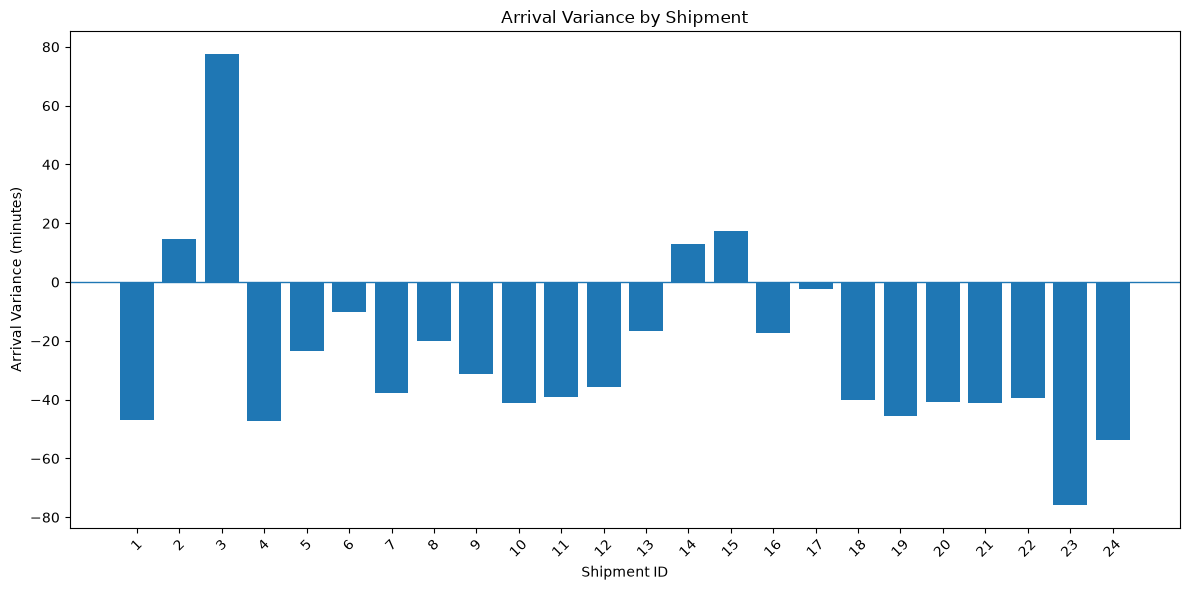

In [21]:
arrival_plot = shipment_classification.sort_values("shipment_id")

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    arrival_plot["shipment_id"].astype(str),
    arrival_plot["arrival_variance_min"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title("Arrival Variance by Shipment")
ax.set_xlabel("Shipment ID")
ax.set_ylabel("Arrival Variance (minutes)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Route performance analysis

Shipment-level metrics can be aggregated by route to examine whether observed
schedule performance differs across transportation lanes.

The analysis compares:

- shipment count
- on-time rate
- average arrival variance
- average transit buffer consumption
- average actual travel duration

Because the current simulation run contains a relatively small number of
shipments per route, these results describe the observed dataset and should not
be interpreted as statistically established route reliability.

In [23]:
route_performance = (
    shipment_route_performance
    .groupby("route_id")
    .agg(
        shipments=("shipment_id", "count"),
        on_time_shipments=("on_time", "sum"),
        avg_arrival_variance_min=("arrival_variance_min", "mean"),
        avg_transit_buffer_consumed_pct=(
            "transit_buffer_consumed_pct",
            "mean",
        ),
        avg_actual_duration_min=("actual_duration_min", "mean"),
        distance_km=("distance_km", "first"),
        baseline_travel_min=("baseline_travel_min", "first"),
    )
    .reset_index()
)

route_performance["on_time_rate_pct"] = (
    route_performance["on_time_shipments"]
    / route_performance["shipments"]
    * 100
)

route_performance[
    [
        "route_id",
        "shipments",
        "on_time_shipments",
        "on_time_rate_pct",
        "avg_arrival_variance_min",
        "avg_transit_buffer_consumed_pct",
        "distance_km",
        "baseline_travel_min",
    ]
].sort_values(
    ["on_time_rate_pct", "avg_arrival_variance_min"],
    ascending=[True, False],
)

,route_id,shipments,on_time_shipments,on_time_rate_pct,avg_arrival_variance_min,avg_transit_buffer_consumed_pct,distance_km,baseline_travel_min
2,3,1,0,0.0,17.316927,138.482059,1100.0,790.0
1,2,1,0,0.0,12.857143,128.571429,1600.0,1145.0
0,1,4,2,50.0,7.187216,15.971592,2200.0,1610.0
4,5,2,2,100.0,-12.986425,71.141277,600.0,470.0
5,6,2,2,100.0,-25.102041,44.217687,1300.0,990.0
7,8,2,2,100.0,-30.408163,32.426304,600.0,455.0
3,4,2,2,100.0,-32.352941,28.104575,2200.0,1650.0
8,9,2,2,100.0,-36.279070,19.379845,550.0,400.0
9,10,2,2,100.0,-40.285714,10.476190,1100.0,800.0
6,7,2,2,100.0,-41.660900,7.420223,1600.0,1130.0


In [24]:
route_sample_sizes = (
    shipment_route_performance
    .groupby("route_id")
    .agg(
        shipments=("shipment_id", "count"),
        vehicles=("vehicle_id", "nunique"),
    )
    .reset_index()
    .sort_values("shipments", ascending=False)
)

route_sample_sizes

,route_id,shipments,vehicles
0,1,4,3
3,4,2,2
4,5,2,2
5,6,2,1
6,7,2,2
7,8,2,2
8,9,2,2
9,10,2,2
10,11,2,2
11,12,2,2


## 11. Shipment analytical feature table

The previous sections analyzed shipment execution, route performance, schedule
buffer, and disruptions separately.

This section combines those dimensions into a single analytical dataset with
one row per shipment.

The resulting feature table provides a convenient foundation for:

- shipment-level comparison
- disruption analysis
- visualization
- statistical analysis
- future anomaly detection and predictive modeling

In [26]:
shipment_disruptions_sql = """
SELECT
    shipment_id,

    COUNT(DISTINCT cause_code) AS disruption_type_count,

    COUNT(*) FILTER (
        WHERE event_type IN (
            'DISRUPTION_STARTED',
            'FUEL_STOP_STARTED',
            'CARGO_EXCEPTION_STARTED'
        )
    ) AS disruption_episode_count,

    STRING_AGG(
        DISTINCT cause_code,
        ', ' ORDER BY cause_code
    ) AS disruption_types

FROM sc_events

WHERE cause_code IS NOT NULL

GROUP BY shipment_id

ORDER BY shipment_id;
"""

shipment_disruptions = pd.read_sql_query(
    shipment_disruptions_sql,
    engine,
)

shipment_disruptions

,shipment_id,disruption_type_count,disruption_episode_count,disruption_types
0,4,1,1,TRAFFIC_CONGESTION
1,5,1,1,TRAFFIC_CONGESTION
2,6,1,1,TRAFFIC_CONGESTION
3,7,1,1,TRAFFIC_CONGESTION
4,8,1,1,TRAFFIC_CONGESTION
5,9,1,1,TRAFFIC_CONGESTION
6,10,1,1,HEAVY_RAIN
7,11,1,1,HEAVY_RAIN
8,12,1,1,HEAVY_RAIN
9,13,1,1,MECHANICAL_BREAKDOWN


In [28]:
shipment_features = shipment_route_performance.merge(
    shipment_classification[
        [
            "shipment_id",
            "performance_class",
        ]
    ],
    on="shipment_id",
    how="left",
)

shipment_features = shipment_features.merge(
    shipment_disruptions,
    on="shipment_id",
    how="left",
)

shipment_features["disruption_type_count"] = (
    shipment_features["disruption_type_count"]
    .fillna(0)
    .astype(int)
)

shipment_features["disruption_episode_count"] = (
    shipment_features["disruption_episode_count"]
    .fillna(0)
    .astype(int)
)

shipment_features["disruption_types"] = (
    shipment_features["disruption_types"]
    .fillna("NONE")
)

In [30]:
print("rows:", len(shipment_features))
print("unique shipments:", shipment_features["shipment_id"].nunique())

rows: 24
unique shipments: 24


In [31]:
shipment_features[
    [
        "shipment_id",
        "vehicle_id",
        "route_id",
        "departure_variance_min",
        "transit_buffer_consumed_pct",
        "arrival_variance_min",
        "on_time",
        "performance_class",
        "disruption_episode_count",
        "disruption_type_count",
        "disruption_types",
    ]
].sort_values("shipment_id")

,shipment_id,vehicle_id,route_id,departure_variance_min,transit_buffer_consumed_pct,arrival_variance_min,on_time,performance_class,disruption_episode_count,disruption_type_count,disruption_types
0,1,1,1,30.0,-70.683883,-46.807747,True,ON_TIME,0,0,NONE
1,2,2,1,60.0,-0.542005,14.756098,False,LATE_DEPARTURE,0,0,NONE
2,3,3,1,90.0,72.462806,77.608263,False,LATE_DEPARTURE,0,0,NONE
3,4,4,4,0.0,-5.228758,-47.352941,True,ON_TIME,1,1,TRAFFIC_CONGESTION
4,5,5,5,0.0,47.863248,-23.461538,True,ON_TIME,1,1,TRAFFIC_CONGESTION
5,6,6,6,0.0,77.551020,-10.102041,True,ON_TIME,1,1,TRAFFIC_CONGESTION
6,7,7,7,0.0,16.147636,-37.733564,True,ON_TIME,1,1,TRAFFIC_CONGESTION
7,8,8,8,0.0,55.555556,-20.000000,True,ON_TIME,1,1,TRAFFIC_CONGESTION
8,9,5,9,0.0,30.490956,-31.279070,True,ON_TIME,1,1,TRAFFIC_CONGESTION
9,10,8,10,0.0,8.253968,-41.285714,True,ON_TIME,1,1,HEAVY_RAIN


## 12. Disruption type and shipment outcome

Operational disruptions do not necessarily result in delivery failure.

This section compares disruption exposure with customer-facing shipment
performance.

The analysis measures:

- number of affected shipments
- on-time rate
- average arrival variance
- average transit buffer consumption

This distinguishes operational disruption severity from final service impact.

In [32]:
disruption_outcomes = (
    shipment_features
    .groupby("disruption_types")
    .agg(
        shipments=("shipment_id", "count"),
        on_time_shipments=("on_time", "sum"),
        avg_arrival_variance_min=(
            "arrival_variance_min",
            "mean",
        ),
        avg_transit_buffer_consumed_pct=(
            "transit_buffer_consumed_pct",
            "mean",
        ),
    )
    .reset_index()
)

disruption_outcomes["on_time_rate_pct"] = (
    disruption_outcomes["on_time_shipments"]
    / disruption_outcomes["shipments"]
    * 100
)

disruption_outcomes[
    [
        "disruption_types",
        "shipments",
        "on_time_shipments",
        "on_time_rate_pct",
        "avg_arrival_variance_min",
        "avg_transit_buffer_consumed_pct",
    ]
].sort_values(
    "on_time_rate_pct"
)

,disruption_types,shipments,on_time_shipments,on_time_rate_pct,avg_arrival_variance_min,avg_transit_buffer_consumed_pct
2,MECHANICAL_BREAKDOWN,5,3,60.0,-1.299586,97.112031
3,NONE,5,3,60.0,-16.840717,-17.423817
0,HEAVY_RAIN,3,3,100.0,-38.721429,13.952379
1,LOW_FUEL_REFUEL,2,2,100.0,-40.282392,10.483573
4,REEFER_TEMP_EXCURSION,3,3,100.0,-42.168868,6.291405
5,TRAFFIC_CONGESTION,6,6,100.0,-28.321526,37.063276


Transit buffer consumption may be negative when actual travel time is faster
than the route baseline. A negative value indicates that transit performance
increased rather than consumed the shipment's available schedule margin.

### Interpreting transit buffer consumption

Transit buffer consumption compares actual travel time with the route baseline
and expresses the difference as a percentage of the available schedule buffer.

- A positive value means transit consumed some of the available schedule buffer.
- A value near 100% means most of the buffer was consumed.
- A value above 100% means transit exceeded the available buffer.
- A negative value means the shipment traveled faster than its route baseline,
  increasing rather than consuming schedule margin.

For example, shipments with no recorded disruption (`NONE`) averaged -17.42%
transit buffer consumption in this run. This indicates better-than-baseline
transit performance; their late shipments resulted from late departures rather
than poor in-transit performance.

## 13. Disruption impact visualization

The following chart compares average transit buffer consumption across
disruption categories.

Higher positive values indicate greater consumption of schedule resilience.
Negative values indicate faster-than-baseline transit performance.

The chart should be interpreted together with on-time performance because
buffer consumption describes transit behavior, not the complete shipment
lifecycle.

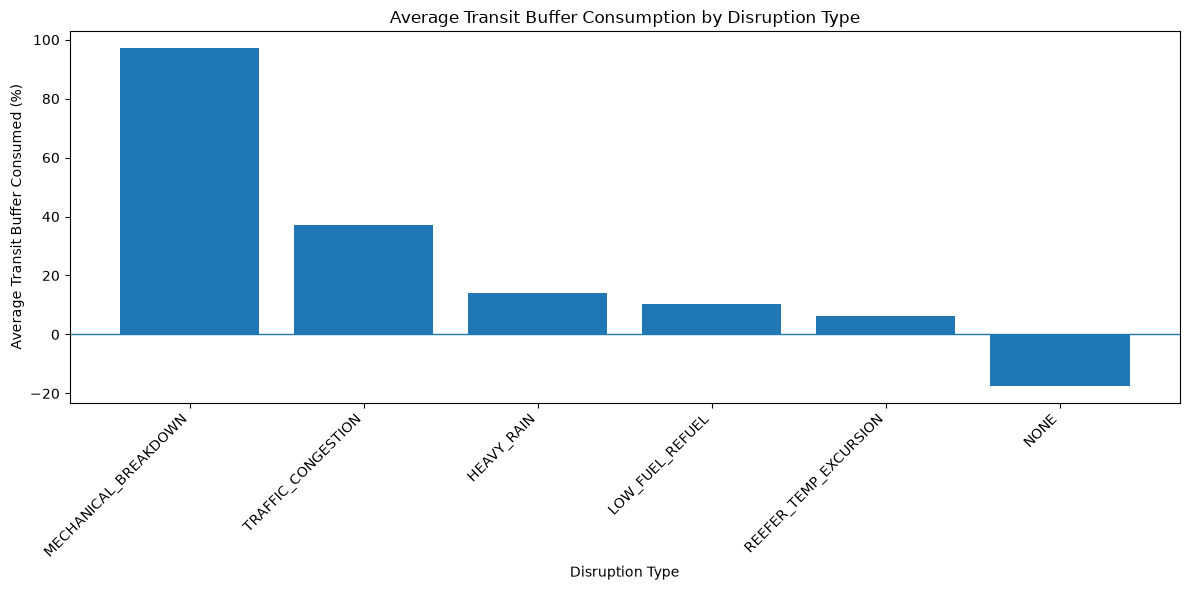

In [34]:
disruption_plot = disruption_outcomes.sort_values(
    "avg_transit_buffer_consumed_pct",
    ascending=False,
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    disruption_plot["disruption_types"],
    disruption_plot["avg_transit_buffer_consumed_pct"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title("Average Transit Buffer Consumption by Disruption Type")
ax.set_xlabel("Disruption Type")
ax.set_ylabel("Average Transit Buffer Consumed (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

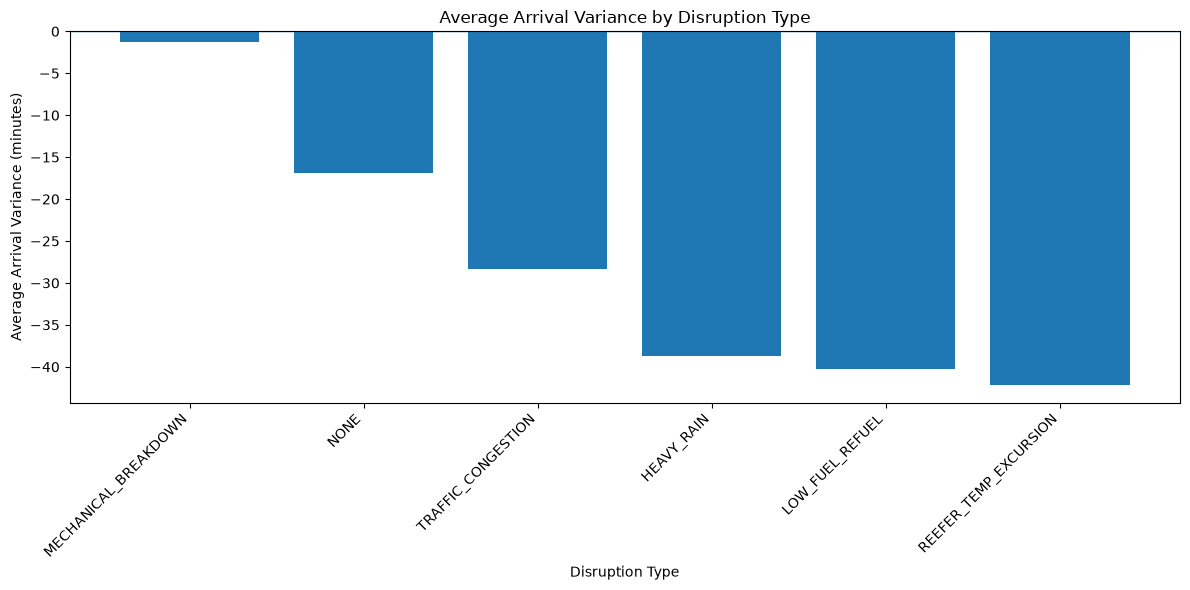

In [35]:
arrival_by_disruption = disruption_outcomes.sort_values(
    "avg_arrival_variance_min",
    ascending=False,
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    arrival_by_disruption["disruption_types"],
    arrival_by_disruption["avg_arrival_variance_min"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title("Average Arrival Variance by Disruption Type")
ax.set_xlabel("Disruption Type")
ax.set_ylabel("Average Arrival Variance (minutes)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. Key findings

This notebook analyzed shipment schedule performance for the current simulation
run and connected shipment outcomes with route characteristics and operational
disruptions.

### Overall shipment performance

- 24 transportation movements were analyzed.
- 20 shipments arrived on time, producing an 83.33% on-time rate.
- 4 shipments arrived late.
- 2 late shipments were associated with late departures.
- 2 late shipments were associated with in-transit mechanical breakdowns.
- 1 additional shipment arrived on time but consumed 94.42% of its transit
  schedule buffer and was classified as `ON_TIME_LOW_MARGIN`.

### Schedule resilience

Each route schedule contained 45 minutes of buffer beyond baseline travel time.

Transit buffer analysis showed that an on-time result does not necessarily imply
a shipment had substantial schedule margin remaining. Shipment 17 arrived only
2.51 minutes early after consuming 94.42% of its available transit buffer.

Negative transit buffer consumption indicates faster-than-baseline travel and
therefore an increase in available schedule margin rather than buffer
consumption.

### Disruption impact

Mechanical breakdown produced the greatest schedule pressure in this run:

- 5 shipments experienced mechanical breakdowns.
- 3 remained on time and 2 arrived late.
- Average transit buffer consumption was 97.11%.
- Average arrival variance was -1.30 minutes.

The near-zero average arrival variance should not be interpreted as negligible
impact. Early and late shipments offset one another in the average, while the
buffer-consumption metric shows substantial underlying schedule pressure.

Traffic congestion affected 6 shipments. All remained on time, although average
transit buffer consumption was 37.06%.

Heavy rain, low-fuel refueling, and reefer temperature excursions produced no
late deliveries in this simulation run.

### Multiple pathways to lateness

The analysis identified two distinct mechanisms that produced late shipments:

1. **Late departure** — shipments 2 and 3 began behind schedule and arrived late
   despite having no recorded in-transit disruption.
2. **Transit delay** — shipments 14 and 15 departed on time but mechanical
   breakdowns exhausted their available transit schedule buffer.

Therefore, absence of an in-transit disruption does not guarantee an on-time
delivery, and presence of a disruption does not necessarily produce a late
delivery.

### Route interpretation

Observed route-level performance should be interpreted cautiously because the
current run contains small samples per route.

Route 1 contains 4 shipments, Routes 2 and 3 contain only 1 shipment each, and
most remaining routes contain 2 shipments. These results describe this
simulation run and are not estimates of long-term route reliability.

## 16. Analytical validation

The final checks verify the grain and internal consistency of the analytical
feature table before the notebook is considered complete.

In [38]:
# One row per shipment
assert len(shipment_features) == 24
assert shipment_features["shipment_id"].nunique() == 24

# No missing shipment classifications
assert shipment_features["performance_class"].notna().all()

# Every shipment has an arrival result
assert shipment_features["arrival_variance_min"].notna().all()
assert shipment_features["on_time"].notna().all()

# Current run contains 20 on-time and 4 late shipments
assert shipment_features["on_time"].sum() == 20
assert (~shipment_features["on_time"]).sum() == 4

# Performance classifications reconcile with shipment outcomes
assert (
    shipment_features["performance_class"] == "LATE_DEPARTURE"
).sum() == 2

assert (
    shipment_features["performance_class"] == "TRANSIT_DELAY"
).sum() == 2

assert (
    shipment_features["performance_class"] == "ON_TIME_LOW_MARGIN"
).sum() == 1

# Disruption counts are never negative
assert (shipment_features["disruption_episode_count"] >= 0).all()
assert (shipment_features["disruption_type_count"] >= 0).all()

print("Notebook validation passed.")

Notebook validation passed.
